# Introduction to the `InSituExperiment` class
## Background

<img src="../../demo_data/demo_screenshots/experiment_levels.jpg" height="300"/>

<p>In addition to the sample, cellular, and subcellular levels, a spatial transcriptomics dataset typically includes an experiment level that contains information about clinical and experimental cohorts, conditions, or treatments. Most current computational frameworks lack functionalities to incorporate this level into the analysis. To address this, <code>InSituPy</code> introduces the <code>InSituExperiment</code> class, which manages spatial transcriptomics data and the corresponding metadata of multiple samples simultaneously.</p>


## Structure
<img src="../../demo_data/demo_screenshots/insituexperiment_structure.jpg" height="200"/>

An `InSituExperiment` object consists of multiple `InSituData` objects paired with their corresponding metadata.

In [1]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

from insitupy import CACHE, InSituData, InSituExperiment

In [3]:
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

### Load Xenium data into `InSituData` object

Now the Xenium data can be parsed by providing the data path to the `InSituPy` project folder.

In [4]:
insitupy_project = Path(CACHE / "out/demo_insitupy_project")
xd = InSituData.read(insitupy_project)
xd

InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
UID:		54743143
Path:		C:\Users\ge37voy\.cache\InSituPy\out\demo_insitupy_project

    ➤ images
       'CD20':     (25778, 35416)
       'HE':       (25778, 35416, 3)
       'HER2':     (25778, 35416)
       'nuclei':   (25778, 35416)
    ➤ cells
       MultiCellData with main layer 'main'
           table
               AnnData object with n_obs × n_vars = 156447 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc_sub_final', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_sub_final_colors', 'cell_type_publ_colors', 'insitupy', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
               obsm: 'X_pca', 'X_umap',

### Create `InSituExperiment`

<img src="../../demo_data/demo_screenshots/insituexperiment_generation.jpg" height="250"/>

*Options to generate an InSituExperiment object*

#### Method 1: Manually add `InSituData` objects

In [5]:
exp = InSituExperiment()
exp.add(
    data=xd,
    metadata={
        "slide_id": xd.slide_id,
        "sample_id": xd.sample_id,
        "patient": "A"
    }
    )

In [6]:
exp

InSituExperiment
Path:		None
    ➤ data
        1 samples
        4 metadata columns:
        "uid", "slide_id", "sample_id", "patient"
        Loaded modalities
            cells: 1/1
            images: 1/1
            transcripts: 1/1
            annotations: 1/1
            regions: 1/1
    ➤ filters
        Base filters: none
        
        Composite filters: none
    ➤ table
        no tables built

In the same way, other datasets can be added. Each dataset needs its own identity (`uid`): adding the *same* `InSituData` object again only refreshes the existing entry (and raises a `ValueError` if the passed `metadata` conflicts with what is already stored). For demonstration we therefore create a second, distinct dataset by cropping a region of `xd`.

In [7]:
# A crop is a new, detached dataset (its uid is None), so add() registers it as a
# separate sample and mints a fresh uid. Re-adding the same `xd` object instead
# would only refresh the existing entry.
xd2 = xd.crop(xlim=(0, 2000), ylim=(0, 2000))
exp.add(
    data=xd2,
    metadata={
        "slide_id": xd.slide_id,
        "sample_id": xd.sample_id,
        "patient": "A",
        "therapy": "drugB"
    }
    )

In [8]:
exp

InSituExperiment
Path:		None
    ➤ data
        2 samples
        5 metadata columns:
        "uid", "slide_id", "sample_id", "patient", "therapy"
        Loaded modalities
            cells: 2/2
            images: 2/2
            transcripts: 2/2
            annotations: 2/2
            regions: 2/2
    ➤ filters
        Base filters: none
        
        Composite filters: none
    ➤ table
        no tables built

#### Method 2: From config file

As config file either a csv file or an excel file can be used.

Example of a valid configuration file:

| directory         | experiment_name | date       | patient    |
|-------------------|-----------------|------------|------------|
| /path/to/dataset1 | Experiment 1    | 2023-09-01 | Patient A  |
| /path/to/dataset2 | Experiment 2    | 2023-09-02 | Patient B  |

In [9]:
import pandas as pd

from insitupy import CACHE

# Define the data
data = {
    "directory": [f"{CACHE}\\out\\demo_insitupy_project", f"{CACHE}\\out\\demo_insitupy_project"],
    "patient": ["A", "B"],
    "therapy": ["drugA", "drugB"]
}

# Create a DataFrame
config_df = pd.DataFrame(data)

# Write the DataFrame to a CSV file
config_df.to_csv('../../demo_data/demo_experiment/insituexperiment_config.csv', index=False)

In [10]:
exp = InSituExperiment.from_config(config="../../demo_data/demo_experiment/insituexperiment_config.csv")

100%|██████████| 2/2 [00:00<00:00, 435.07it/s]


In [11]:
exp

InSituExperiment
Path:		None
    ➤ data
        2 samples
        3 metadata columns:
        "uid", "patient", "therapy"
        Loaded modalities
            None.
    ➤ filters
        Base filters: none
        
        Composite filters: none
    ➤ table
        no tables built

In [12]:
exp.load_all()

100%|██████████| 2/2 [00:06<00:00,  3.11s/it]


In [13]:
exp

InSituExperiment
Path:		None
    ➤ data
        2 samples
        3 metadata columns:
        "uid", "patient", "therapy"
        Loaded modalities
            cells: 2/2
            images: 2/2
            transcripts: 2/2
            annotations: 2/2
            regions: 2/2
    ➤ filters
        Base filters: none
        
        Composite filters: none
    ➤ table
        no tables built

#### Method 3: From regions

We can also use regions from an `InSituData` object to split the data into separate datasets and create an `InSituExperiment` from them. This can be used to select the most interesting regions and focus on them for the analysis or to split a TMA dataset into separate datasets for each core.

In [14]:
exp = InSituExperiment.from_regions(
    data=xd, region_key="TMA"
)

C:\Users\ge37voy\AppData\Local\Temp\ipykernel_33788\2821298324.py:1: UserWarning: Transcript data will be loaded into memory to speed up region cropping. This may require substantial RAM for large datasets.
  exp = InSituExperiment.from_regions(


2026-10-07 15:50:18 | [INFO] Loading transcripts into memory...
2026-10-07 15:50:21 | [INFO] Transcripts loaded: 42,638,083 rows.


Iterating regions: 100%|██████████| 6/6 [00:21<00:00,  3.62s/it]


In [15]:
exp

InSituExperiment
Path:		None
    ➤ data
        6 samples
        3 metadata columns:
        "uid", "region_key", "region_name"
        Loaded modalities
            cells: 6/6
            images: 6/6
            transcripts: 6/6
            annotations: 6/6
            regions: 6/6
    ➤ filters
        Base filters: none
        
        Composite filters: none
    ➤ table
        no tables built

## Work with viewer windows and `InSituExperiment`

One can interactively display the data for individual datasets inside an `InSituExperiment` using `.show(<index>)`, where `<index>` specifies the index of the data in the metadata. Since version `0.9.0` multiple viewer windows can be opened in parallel. In the napari window annotations can be made and synced back to the data in `InSituExperiment` using the "Sync Geometries" button on the bottom right.

In [16]:
# visualize data
exp.show(3)

2026-10-07 15:50:46 | [INFO] No OpenGL_accelerate module loaded: No module named 'OpenGL_accelerate'


2026-10-07 15:50:53 | [INFO] Extracting unique gene names from Dask DataFrame...
2026-10-07 15:50:54 | [INFO] Found 541 unique genes


Example screenshot of data from one of the cropped cores:

<img src="../../demo_data/demo_screenshots/TMA_example.jpg" class="center" height="300"/>

## Plot overview of metadata and QC metrics

In [17]:
from insitupy.plotting import overview

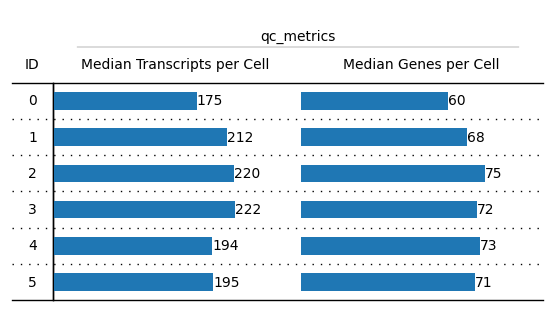

In [18]:
overview(exp)

In [ ]:
overview(exp, cells_layer="main", columns_to_plot=["uid", "region_name", "region_key"], index=True)

## Iterate through `InSituExperiment`

The `.iterdata()` method returns a generator object, allowing you to iterate through the metadata and data of each dataset in the `InSituExperiment`. The individual datasets are returned as `InSituData` objects.

In [ ]:
for metadata, data in exp.iterdata():
    print(f"Metadata:\n{metadata[:3]}\nData:\n{data}")

Metadata:
uid             d5933ddc
slide_id         0001879
sample_id    Replicate 1
Name: 0, dtype: object
Data:
InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		None

    âž¤ images
       CD20:	(4706, 4706)
       HE:	(4706, 4706, 3)
       HER2:	(4706, 4706)
       nuclei:	(4706, 4706)
    âž¤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs Ã— n_vars = 4847 Ã— 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_publ_colors', 'cell_type_tacco_colors', 'cou

## Add new metadata

In the following section different scenarios for adding new metadata are shown.

In [20]:
exp1 = InSituExperiment.from_regions(
    data=xd, region_key="demo_regions"
)

C:\Users\ge37voy\AppData\Local\Temp\ipykernel_33788\3806008386.py:1: UserWarning: Transcript data will be loaded into memory to speed up region cropping. This may require substantial RAM for large datasets.
  exp1 = InSituExperiment.from_regions(


2026-10-07 15:52:35 | [INFO] Loading transcripts into memory...
2026-10-07 15:52:39 | [INFO] Transcripts loaded: 42,638,083 rows.


Iterating regions: 100%|██████████| 3/3 [00:14<00:00,  4.69s/it]


In [21]:
exp1

InSituExperiment
Path:		None
    ➤ data
        3 samples
        3 metadata columns:
        "uid", "region_key", "region_name"
        Loaded modalities
            cells: 3/3
            images: 3/3
            transcripts: 3/3
            annotations: 3/3
            regions: 3/3
    ➤ filters
        Base filters: none
        
        Composite filters: none
    ➤ table
        no tables built

In [22]:
exp2 = exp1.copy()
exp2.append_metadata(
    new_metadata="../../demo_data/demo_experiment/insituexperiment_new_metadata.csv",
    by="region_name", overwrite=True
)

In [23]:
exp2

InSituExperiment
Path:		None
    ➤ data
        3 samples
        6 metadata columns:
        "uid", "region_name", "therapy", "organ", "test", "region_key"
        Loaded modalities
            cells: 3/3
            images: 3/3
            transcripts: 3/3
            annotations: 3/3
            regions: 3/3
    ➤ filters
        Base filters: none
        
        Composite filters: none
    ➤ table
        no tables built

In [24]:
exp3 = exp1.copy()
exp3.append_metadata(
    new_metadata="../../demo_data/demo_experiment/insituexperiment_new_metadata.csv",
    by="region_name", overwrite=False
)

In [25]:
exp3

InSituExperiment
Path:		None
    ➤ data
        3 samples
        6 metadata columns:
        "uid", "region_key", "region_name", "organ", "test", "therapy"
        Loaded modalities
            cells: 3/3
            images: 3/3
            transcripts: 3/3
            annotations: 3/3
            regions: 3/3
    ➤ filters
        Base filters: none
        
        Composite filters: none
    ➤ table
        no tables built

In [26]:
exp4 = exp1.copy()
exp4.append_metadata(
    new_metadata="../../demo_data/demo_experiment/insituexperiment_new_metadata2.csv",
    by="region_name", overwrite=False
)

In [27]:
exp4

InSituExperiment
Path:		None
    ➤ data
        3 samples
        6 metadata columns:
        "uid", "region_key", "region_name", "organ", "test", "therapy"
        Loaded modalities
            cells: 3/3
            images: 3/3
            transcripts: 3/3
            annotations: 3/3
            regions: 3/3
    ➤ filters
        Base filters: none
        
        Composite filters: none
    ➤ table
        no tables built

In [28]:
exp5 = exp1.copy()
exp5.append_metadata(
    new_metadata="../../demo_data/demo_experiment/insituexperiment_new_metadata2.csv",
    by="region_name", overwrite=True
)

In [29]:
exp5

InSituExperiment
Path:		None
    ➤ data
        3 samples
        6 metadata columns:
        "uid", "region_name", "therapy", "organ", "test", "region_key"
        Loaded modalities
            cells: 3/3
            images: 3/3
            transcripts: 3/3
            annotations: 3/3
            regions: 3/3
    ➤ filters
        Base filters: none
        
        Composite filters: none
    ➤ table
        no tables built

Concatenate multiple `InSituExperiment` objects

In [30]:
exp

InSituExperiment
Path:		None
    ➤ data
        6 samples
        3 metadata columns:
        "uid", "region_key", "region_name"
        Loaded modalities
            cells: 6/6
            images: 6/6
            transcripts: 6/6
            annotations: 6/6
            regions: 6/6
    ➤ filters
        Base filters: none
        
        Composite filters: none
    ➤ table
        no tables built

In [31]:
exp1

InSituExperiment
Path:		None
    ➤ data
        3 samples
        3 metadata columns:
        "uid", "region_key", "region_name"
        Loaded modalities
            cells: 3/3
            images: 3/3
            transcripts: 3/3
            annotations: 3/3
            regions: 3/3
    ➤ filters
        Base filters: none
        
        Composite filters: none
    ➤ table
        no tables built

In [32]:
exp_concat = InSituExperiment.concat(
    objs={
        "exp_TMA": exp,
        "exp_demo_regions": exp1
    },
    new_col_name="name"
    )

2026-10-07 15:53:07 | [WARNING] Observation names are not unique across all datasets.


In [33]:
exp_concat

InSituExperiment
Path:		None
    ➤ data
        9 samples
        4 metadata columns:
        "uid", "region_key", "region_name", "name"
        Loaded modalities
            cells: 9/9
            images: 9/9
            transcripts: 9/9
            annotations: 9/9
            regions: 9/9
    ➤ filters
        Base filters: none
        
        Composite filters: none
    ➤ table
        no tables built

In [34]:
exp_concat = InSituExperiment.concat(
    objs=[exp, exp1])

2026-10-07 15:53:09 | [WARNING] Observation names are not unique across all datasets.


In [35]:
exp_concat

InSituExperiment
Path:		None
    ➤ data
        9 samples
        3 metadata columns:
        "uid", "region_key", "region_name"
        Loaded modalities
            cells: 9/9
            images: 9/9
            transcripts: 9/9
            annotations: 9/9
            regions: 9/9
    ➤ filters
        Base filters: none
        
        Composite filters: none
    ➤ table
        no tables built

The following diagram summarises the dataset-level operations available on `InSituExperiment`.

<img src="../../_static/img/insituexperiment_dataset_ops.svg" width="100%"/>

## Indexing and selection of data within `InSituExperiment`

The `InSituExperiment` class allows simple selection and filtering of data using indices or True/False masks.

### Example 1: Select datasets by index

In [36]:
exp_indexed = exp_concat[:3]

In [37]:
exp_indexed

InSituExperimentView
Path:		None
    ➤ data
        3 samples
        3 metadata columns:
        "uid", "region_key", "region_name"
        Loaded modalities
            cells: 3/3
            images: 3/3
            transcripts: 3/3
            annotations: 3/3
            regions: 3/3
    ➤ filters
        Base filters: none
        
        Composite filters: none
    ➤ table
        no tables built

In [38]:
exp_indexed.show(2)

2026-10-07 15:56:57 | [WARNING] QWindowsWindow::setGeometry: Unable to set geometry 1626x980+801+392 (frame: 1648x1036+790+347) on QWidgetWindow/"_QtMainWindowClassWindow" on "\\.\DISPLAY1". Resulting geometry: 2441x1473+804+406 (frame: 2463x1529+793+361) margins: 11, 45, 11, 11 minimum size: 283x506 MINMAXINFO maxSize=0,0 maxpos=0,0 mintrack=447,815 maxtrack=0,0)


2026-10-07 15:56:58 | [INFO] Extracting unique gene names from Dask DataFrame...
2026-10-07 15:56:58 | [INFO] Found 540 unique genes


Also a list of indices can be used for this.

In [39]:
exp_concat[[0,1,4]]

InSituExperimentView
Path:		None
    ➤ data
        3 samples
        3 metadata columns:
        "uid", "region_key", "region_name"
        Loaded modalities
            cells: 3/3
            images: 3/3
            transcripts: 3/3
            annotations: 3/3
            regions: 3/3
    ➤ filters
        Base filters: none
        
        Composite filters: none
    ➤ table
        no tables built

### Example 2: Select only datasets with a "1" in the region name using a mask

In [40]:
filtering_mask = exp_concat.metadata["region_name"].str.contains("1", na=False) # NaN values are filled with False
exp_filtered = exp_concat[filtering_mask]

### Example 3: Query data

The `.query()` function can be used to the [`pandas.DataFrame.query`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.query.html) function.

In [41]:
exp_concat.query(
    criteria="region_key == 'demo_regions'"
)

InSituExperimentView
Path:		None
    ➤ data
        3 samples
        3 metadata columns:
        "uid", "region_key", "region_name"
        Loaded modalities
            cells: 3/3
            images: 3/3
            transcripts: 3/3
            annotations: 3/3
            regions: 3/3
    ➤ filters
        Base filters: none
        
        Composite filters: none
    ➤ table
        no tables built

## Save `InSituExperiment`

In [42]:
exp_concat.saveas(CACHE / "out/test_insituexperiment", overwrite=True)

100%|██████████| 9/9 [01:32<00:00, 10.32s/it]

Collected warnings:
  [UnstableSpecificationWarning] The data type (FixedLengthUTF32(length=5, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3. (x6)
  [UnstableSpecificationWarning] The data type (FixedLengthUTF32(length=6, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-t

## Reload `InSituExperiment`

In [43]:
exp_reloaded = InSituExperiment.read(CACHE / "out/test_insituexperiment/")

100%|██████████| 9/9 [00:00<00:00, 1076.14it/s]


In [44]:
exp_reloaded.load_all()

100%|██████████| 9/9 [00:07<00:00,  1.22it/s]


In [45]:
exp_reloaded

InSituExperiment
Path:		C:\Users\ge37voy\.cache\InSituPy\out\test_insituexperiment
    ➤ data
        9 samples
        3 metadata columns:
        "uid", "region_key", "region_name"
        Loaded modalities
            cells: 9/9
            images: 9/9
            transcripts: 9/9
            annotations: 9/9
            regions: 9/9
    ➤ filters
        Base filters: none
        
        Composite filters: none
    ➤ table
        no tables built

In [46]:
exp_reloaded.show(2)

2026-10-07 16:03:11 | [INFO] Extracting unique gene names from Dask DataFrame...
2026-10-07 16:03:11 | [INFO] Found 540 unique genes


In [47]:
exp_reloaded.save()

100%|██████████| 9/9 [00:30<00:00,  3.33s/it]

Collected warnings:
  [UnstableSpecificationWarning] The data type (FixedLengthUTF32(length=5, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3. (x6)
  [UnstableSpecificationWarning] The data type (FixedLengthUTF32(length=6, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-t

In [48]:
exp_reloaded = InSituExperiment.read(CACHE / "out/test_insituexperiment/")

100%|██████████| 9/9 [00:00<00:00, 1138.24it/s]


In [49]:
exp_reloaded.load_all()

100%|██████████| 9/9 [00:06<00:00,  1.40it/s]


In [50]:
exp_reloaded.data[2]

InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
UID:		aa34b663
Path:		C:\Users\ge37voy\.cache\InSituPy\out\test_insituexperiment\data-002

    ➤ images
       'CD20':     (4706, 4705)
       'HE':       (4706, 4705, 3)
       'HER2':     (4706, 4705)
       'nuclei':   (4706, 4705)
    ➤ cells
       MultiCellData with main layer 'main'
           table
               AnnData object with n_obs × n_vars = 1807 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc_sub_final', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_sub_final_colors', 'cell_type_publ_colors', 'insitupy', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
               obsm: 'X_pca', 'X_umap', 

In [52]:
exp_reloaded.show(2)

2026-10-07 16:18:34 | [WARNING] QWindowsWindow::setGeometry: Unable to set geometry 1626x980-811+503 (frame: 1648x1036-822+458) on QWidgetWindow/"_QtMainWindowClassWindow" on "\\.\DISPLAY1". Resulting geometry: 2441x1473-808+517 (frame: 2463x1529-819+472) margins: 11, 45, 11, 11 minimum size: 283x506 MINMAXINFO maxSize=0,0 maxpos=0,0 mintrack=447,815 maxtrack=0,0)


2026-10-07 16:18:35 | [INFO] Extracting unique gene names from Dask DataFrame...
2026-10-07 16:18:35 | [INFO] Found 540 unique genes


INFO: Added 2 new annotations to key 'test'


Annotations or regions can now be added to the individual datasets and by pressing the "Sync Geometries" button they are saved in the corresponding `InSituData` object:

In [53]:
exp_reloaded.data[2]

InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
UID:		aa34b663
Path:		C:\Users\ge37voy\.cache\InSituPy\out\test_insituexperiment\data-002

    ➤ images
       'CD20':     (4706, 4705)
       'HE':       (4706, 4705, 3)
       'HER2':     (4706, 4705)
       'nuclei':   (4706, 4705)
    ➤ cells
       MultiCellData with main layer 'main'
           table
               AnnData object with n_obs × n_vars = 1807 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc_sub_final', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_sub_final_colors', 'cell_type_publ_colors', 'insitupy', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
               obsm: 'X_pca', 'X_umap', 